# 1. Introduction

For this project we will interpret data from the National Parks Service about endangered species in different parks. 
We will perform data analysis on the conservation status of species and investigate if there are any patterns or themes to the types of species that become endangered. 
We will perform data clean, carry out analysis and develop visualizations as well as pose questions and seek answers to these questions in meaningful ways. 

## 1.1 Key Analysis Areas: 
-------------------

- evaluate the distribution of conservation statuses across the different categories - determine if specific groups face higher risk of endagerment \
(e.g, do mammals have more animals in endangered than birds? etc.) 
- aggregate the number of sightings per park for all species to evaluate which locations host the greatest biodiversity. Which parks have the greatest sightings of rare species? 
- identify the top 100 rarest species based on total observations across the entire park system. Define if rare species fit into engangered category 
- isolate sightings of rare species and calculate the observation density for each park - account for varying scales of data collection and park size to identify conservation hotspots 

# 2. Data Cleaning and Inspection 
### Import Libraries and Load Data 

Import data from both csv's and analyze them separate to ensure these are clean.  

<code>observations.csv</code> is loaded into DataFrame called <code>df_observations</code> \
<code>species_info.csv</code> is loaded into <code>df_species_info</code>

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Import csv's into separate data frames 
df_observations = pd.read_csv('observations.csv')
df_species_info = pd.read_csv('species_info.csv')

#### Observations

<code>observations.csv</code> contains information on the observations per park, including: 
- scientific name - name of specific species 
- park name - name of specific park 
- observations - # of observations for species at a specific park 

The observations data set has 23,296 records. 

In [2]:
print('observations (rows, columns): ', df_observations.shape)
print('')
df_observations.head()

observations (rows, columns):  (23296, 3)



,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


#### Species Info

<code>species_info.csv</code> contains information on the species, including: 
- category (biologicial description) 
- scientific name - name of specific species 
- common name - name of specific species 
- conservation status - conservation status for that species 

The species info data set has 5,824 records. 

In [3]:
print('species info (rows, columns): ', df_species_info.shape)
print('')
df_species_info.head()

species info (rows, columns):  (5824, 4)



,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,NaN
1,Mammal,Bos bison,"American Bison, Bison",NaN
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",NaN
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",NaN
4,Mammal,Cervus elaphus,Wapiti Or Elk,NaN


---------------------------------------
## 2.1  <code>species_info.csv</code>
---------------------------------------
### 2.1.1 Data Characteristics
<code>species_info.csv</code> has 5,824 records with 4 columns. These columns include the following unique values: 
-    Category: <b>[Mammal, Bird, Repitle, Amphibian, Fish, Vascular Plant, Nonvascular Plant]</b>

-    scientific names (unique): <b>5,541</b> 

-    common names (unique): <b>5,541</b>

-    Conservation Statuses : <b>[NaN, Species of Concern, Endangered, Threatened, In Recovery]</b>
---------------------------------------

In [4]:
print('species_info.csv:')
print(f'rows: {df_species_info.shape[0]}')
print(f'columns: {df_species_info.shape[1]}')
print(f"\nCategories: {df_species_info['category'].unique()}")
print(f"\nNumber of species (Scientific Names): {df_species_info['scientific_name'].nunique()}")
print(f"Number of species (common Names): {df_species_info['scientific_name'].nunique()}")
print(f"Conservation Statuses: {df_species_info['conservation_status'].unique()}")

species_info.csv:
rows: 5824
columns: 4

Categories: ['Mammal' 'Bird' 'Reptile' 'Amphibian' 'Fish' 'Vascular Plant'
 'Nonvascular Plant']

Number of species (Scientific Names): 5541
Number of species (common Names): 5541
Conservation Statuses: [nan 'Species of Concern' 'Endangered' 'Threatened' 'In Recovery']


---------------------------------------
### 2.1.2 Missing Values & Duplicates 

By counting the number of values in each of the columns, we can identify "missing" values in our data. 

| Column | Value / Count |
| ---: | ---: |
| **category** | 5824 | 
| **scientific_name** | 5824 | 
| **common_name** | 5824 | 
| **conservation_status** | 191 |

The conservation status is missing >95% values (5,633 rows). We will need to change NaN into something more descriptive - e.g., Not Evaluated, Data Deficient, etc..

#### Duplicate Values 

Next we look at "duplicate" rows. There are 283 duplicates with the same scientific name - these could having duplicates of category, common name or conservation status.
- 5,824 total records 
- 5,541 unique scientific names 
- 283 duplicate 

A total of 283 records have duplicated scientific names. We found that 281 records have the same conservation status for every scientific name. \
This means there are two records w/ the same scientific name which have different conservation status.   

---------------------------------------

In [5]:
print('species_info.csv:')
print('Number of Rows: ')
print(df_species_info.count())
print('')
maxRows = df_species_info['scientific_name'].count()
print('Missing Rows: ')
print(maxRows - df_species_info.count())
print('')

species_info.csv:
Number of Rows: 
category               5824
scientific_name        5824
common_names           5824
conservation_status     191
dtype: int64

Missing Rows: 
category                  0
scientific_name           0
common_names              0
conservation_status    5633
dtype: int64



In [6]:
duplicates = df_species_info[df_species_info.duplicated(subset=['scientific_name'])].sort_values(by='scientific_name')
duplicates.count()

category               283
scientific_name        283
common_names           283
conservation_status     13
dtype: int64

In [7]:
duplicates_2 = df_species_info[df_species_info.duplicated(subset=['scientific_name', 'conservation_status'])]
duplicates_2.count()

category               281
scientific_name        281
common_names           281
conservation_status     11
dtype: int64

---------------------------------------
### 2.1.3 Dealing with Missing Values - Filling NaN 
First, we will fill the NaN values in conservation status with "Data Deficient". We choose to state "Data Deficient" as we might be able to find species not observed in multiple \
parks and give some predictor to the conservation status of species based on the number of observations across the board - i.e. assuming these are safe species could be dangerous. 

---------------------------------------

In [8]:
species_test = df_species_info.copy()
species_test = species_test.drop_duplicates(subset=['scientific_name', 'conservation_status']).reset_index()
species_test = species_test.drop(columns=['index'])
species_test['conservation_status'] = species_test['conservation_status'].fillna('Data Deficient')
species_test.head()

,category,scientific_name,common_names,conservation_status
0,Mammal,Clethrionomys gapperi gapperi,Gapper's Red-Backed Vole,Data Deficient
1,Mammal,Bos bison,"American Bison, Bison",Data Deficient
2,Mammal,Bos taurus,"Aurochs, Aurochs, Domestic Cattle (Feral), Dom...",Data Deficient
3,Mammal,Ovis aries,"Domestic Sheep, Mouflon, Red Sheep, Sheep (Feral)",Data Deficient
4,Mammal,Cervus elaphus,Wapiti Or Elk,Data Deficient


---------------------------------------
### 2.1.3 Dealing With Duplicates

#### Order Categorical Data 

We order conservation_status (<b>'Endangered' > 'Threatened' > 'Species of Concern' > 'In Recovery' > 'Data Deficient' </b>). \
This is done to ensure that we keep the more relevant of the two statuses whenever a scientific name statues multiple. \
e.g., a species is recorded as both "engangered" and "data deficient" we want to keep the "endangered" status. 

---------------------------------------

In [9]:
custom_order = ['Endangered', 'Threatened', 'Species of Concern', 'In Recovery', 'Data Deficient']

from pandas.api.types import CategoricalDtype 

cat_type = CategoricalDtype(categories=custom_order, ordered=True)

species_test['conservation_status'] = species_test['conservation_status'].astype(cat_type)
species_test = species_test.sort_values('conservation_status')

species_test.head()

,category,scientific_name,common_names,conservation_status
4388,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered
34,Mammal,Myotis grisescens,Gray Myotis,Endangered
276,Bird,Vermivora bachmanii,"Bachman's Warbler, Bachman's Wood Warbler",Endangered
343,Bird,Picoides borealis,Red-Cockaded Woodpecker,Endangered
540,Fish,Etheostoma percnurum,Duskytail Darter,Endangered


---------------------------
#### Dealing With Duplicates

There are two duplicates (2 canis lupus and 2 oncorhynchus mykiss) with different conservation_status. 

| Category | Scientific Name | Common Names | Conservation Status |
| :--- | :---: | :---: | :---: |
| Mammal | *Canis lupus* | Gray Wolf | Endangered |
| Mammal | *Canis lupus* | Gray Wolf, Wolf | In Recovery |
| Fish | *Oncorhynchus mykiss* | Rainbow Trout | Threatened |
| Fish | *Oncorhynchus mykiss* | Rainbow Trout | Data Deficient |

With the ordering we applied, we have the first entry of each as the most relevant conservation status that we'd want to consider. \
We can keep the first instance of duplicates and drop second duplicates, and reset index so as to have a clean dataset. 

We've handled all the duplicates in species_info, and now have a clean dataset ready for analysis. 

---------------------------

In [10]:
duplicated_data = species_test[species_test.duplicated(subset=['scientific_name'], keep=False)]
duplicated_data.sort_values(by='scientific_name')

,category,scientific_name,common_names,conservation_status
8,Mammal,Canis lupus,Gray Wolf,Endangered
3018,Mammal,Canis lupus,"Gray Wolf, Wolf",In Recovery
3247,Fish,Oncorhynchus mykiss,Rainbow Trout,Threatened
560,Fish,Oncorhynchus mykiss,Rainbow Trout,Data Deficient


In [11]:
species_test2 = species_test.drop_duplicates(subset=['scientific_name'], keep='first').reset_index()
species_test2.head()

,index,category,scientific_name,common_names,conservation_status
0,4388,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered
1,34,Mammal,Myotis grisescens,Gray Myotis,Endangered
2,276,Bird,Vermivora bachmanii,"Bachman's Warbler, Bachman's Wood Warbler",Endangered
3,343,Bird,Picoides borealis,Red-Cockaded Woodpecker,Endangered
4,540,Fish,Etheostoma percnurum,Duskytail Darter,Endangered


In [12]:
print(species_test2.loc[species_test2['scientific_name'] == 'Canis lupus'])
print('')
print(species_test2.loc[species_test2['scientific_name'] == 'Oncorhynchus mykiss'])

   index category scientific_name common_names conservation_status
7      8   Mammal     Canis lupus    Gray Wolf          Endangered

    index category      scientific_name   common_names conservation_status
20   3247     Fish  Oncorhynchus mykiss  Rainbow Trout          Threatened


In [13]:
print('Duplicate by Category & Scientific Name: \n', species_test2.duplicated(subset=['scientific_name', 'category']).value_counts())
print('Duplicate by common name & Scientific Name: \n', species_test2.duplicated(subset=['scientific_name', 'common_names']).value_counts())
print('Duplicate by conservation status & Scientific Name: \n', species_test2.duplicated(subset=['scientific_name', 'conservation_status']).value_counts())

Duplicate by Category & Scientific Name: 
 False    5541
dtype: int64
Duplicate by common name & Scientific Name: 
 False    5541
dtype: int64
Duplicate by conservation status & Scientific Name: 
 False    5541
dtype: int64


---------------------------
#### Caveat: 

Note that the species_info.csv table may produced by appending new status updates to a master file over several years. \
e.g., Canis Lupus moved from "Engangered" to "In Recovery" due to a later data input some time later. \
If we could have reason to believe the file is organized chronologically, then lowest entry on the list for a specific scientific name would be the most accurate. \
(i.e. logging systems where new status updates are appended to the end of the file)

However, biodiversity data may come from different sources - e.g., one entry reflects federal status while another reflects state-level status. \
In these cases, taking the "latest" record may prioritize a less severe status just because it was the last one entered into the spreadsheet.\
Since we are aiming for a clean dataset, the most robust path is to use the hierarchy of importance. \
Therefore, For species with multiple records, we have retained the status representing the highest level of conservation concern.

---------------------------
## 2.2 <code>observations.csv</code>

---------------------------
### 2.2.1 Data Characteristics
<code>observations.csv</code> has 23,296 records with 3 columns. These columns include: 

-    scientific names (unique): <b>5,541</b> 
-    park name: <b>['Great Smoky Mountains National Park', 'Yosemite National Park',
 'Bryce National Park', 'Yellowstone National Park']</b>
-    observations : <b>(1,2,3...,n)</b>
---------------------------------------


In [14]:
df_observations.head()

,scientific_name,park_name,observations
0,Vicia benghalensis,Great Smoky Mountains National Park,68
1,Neovison vison,Great Smoky Mountains National Park,77
2,Prunus subcordata,Yosemite National Park,138
3,Abutilon theophrasti,Bryce National Park,84
4,Githopsis specularioides,Great Smoky Mountains National Park,85


In [15]:
print("observations.csv:")
print(f"number of species: {df_observations['scientific_name'].nunique()}")
print(f"parks: {df_observations['park_name'].unique()}")

observations.csv:
number of species: 5541
parks: ['Great Smoky Mountains National Park' 'Yosemite National Park'
 'Bryce National Park' 'Yellowstone National Park']


---------------------------------------
### 2.2.2 Missing Values & Duplicates 

By counting the number of values in each of the columns, we can identify "missing" values in our data. 

| Column | Value / Count |
| ---: | ---: |
| **scientific_name** | 23,296 | 
| **park_name** | 23,296 | 
| **observations** | 23,296 |

(i.e.: no missing  values)

#### Duplicate Values 

Species were recorded multiple times for each park, therefore we must add the number of observations for each species per park, to get the total observations per park. 

---------------------------------------

In [16]:
print('observations.csv:')
print('Number of Rows: ')
df_observations.count()

observations.csv:
Number of Rows: 


scientific_name    23296
park_name          23296
observations       23296
dtype: int64

In [17]:
duplicates = df_observations.duplicated(subset=['scientific_name', 'park_name'])
print(duplicates.value_counts())

False    22164
True      1132
dtype: int64


In [18]:
df_observations[['scientific_name', 'park_name']].groupby('park_name').count()

,scientific_name
park_name,
Bryce National Park,5824
Great Smoky Mountains National Park,5824
Yellowstone National Park,5824
Yosemite National Park,5824


In [19]:
observation_data = df_observations.groupby(['park_name', 'scientific_name'])['observations'].sum().reset_index()
observation_data

,park_name,scientific_name,observations
0,Bryce National Park,Abies bifolia,109
1,Bryce National Park,Abies concolor,83
2,Bryce National Park,Abies fraseri,109
3,Bryce National Park,Abietinella abietina,101
4,Bryce National Park,Abronia ammophila,92
...,...,...,...
22159,Yosemite National Park,Zonotrichia leucophrys gambelii,169
22160,Yosemite National Park,Zonotrichia leucophrys oriantha,135
22161,Yosemite National Park,Zonotrichia querula,160
22162,Yosemite National Park,Zygodon viridissimus,159


In [20]:
print('number of duplicate species per park: ', 5824 - 5541)
print('283 (duplicates) * 4 (parks) = ', 283 * 4)
print('(i.e. the number of duplicates per park match the total number of duplicates on the entire dataset)')

number of duplicate species per park:  283
283 (duplicates) * 4 (parks) =  1132
(i.e. the number of duplicates per park match the total number of duplicates on the entire dataset)


---------------------------
## 2.3 Merging Data Sets
---------------------------

#### Data Clean Completion
Our master table now contains all information available (category, scientific and common name, park location, number of observations per park, and conservation status for species). 
We have a total of 22,164 records (5,541 * 4 = 22,164 records), accounting for the 5,541 unique species across 4 different national parks. Note that our code here will enable us to include more parks or species down the road if data becomes available. 

---------------------------

In [21]:
species_test2 = species_test2.drop(columns=['index']) 
species_test2

,category,scientific_name,common_names,conservation_status
0,Amphibian,Rana sierrae,Sierra Nevada Yellow-Legged Frog,Endangered
1,Mammal,Myotis grisescens,Gray Myotis,Endangered
2,Bird,Vermivora bachmanii,"Bachman's Warbler, Bachman's Wood Warbler",Endangered
3,Bird,Picoides borealis,Red-Cockaded Woodpecker,Endangered
4,Fish,Etheostoma percnurum,Duskytail Darter,Endangered
...,...,...,...,...
5536,Vascular Plant,Oenothera fruticosa ssp. fruticosa,Sundrops,Data Deficient
5537,Vascular Plant,Oenothera biennis,"Common Evening-Primrose, Evening Primrose",Data Deficient
5538,Vascular Plant,Ludwigia uruguayensis,Seedbox,Data Deficient
5539,Vascular Plant,Nuphar lutea ssp. advena,Yellow Water-Lily,Data Deficient


In [22]:
master_df = pd.merge(observation_data, species_test2, how='left')

print(master_df.isnull().sum())

new_order = ['category', 'scientific_name', 'common_names', 'park_name', 'observations', 'conservation_status']

master_df = master_df[new_order]

park_name              0
scientific_name        0
observations           0
category               0
common_names           0
conservation_status    0
dtype: int64


In [23]:
master_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 22164 entries, 0 to 22163
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   category             22164 non-null  object  
 1   scientific_name      22164 non-null  object  
 2   common_names         22164 non-null  object  
 3   park_name            22164 non-null  object  
 4   observations         22164 non-null  int64   
 5   conservation_status  22164 non-null  category
dtypes: category(1), int64(1), object(4)
memory usage: 1.0+ MB


-----------------------
# 3. Data Analysis
-----------------------

## 3.1 Prilimiary Analysis

We begin by gaining a basic understanding on our data. Which are the most abundant species? Is there a vast disparity in #observations for specific categories? \
Predictably, plant species are the most abundant, 

In [24]:
categories_df = master_df.groupby(['category'])['observations'].sum().reset_index()
categories_df.sort_values(by='observations', ascending=False)

,category,observations
6,Vascular Plant,2555090
1,Bird,292833
4,Nonvascular Plant,190653
3,Mammal,116696
2,Fish,70818
5,Reptile,44678
0,Amphibian,43971


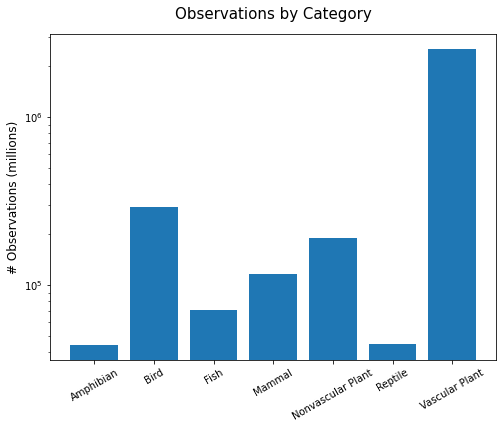

In [25]:
fig, ax = plt.subplots(figsize=(8,6))

plt.bar(categories_df['category'], categories_df['observations']);
plt.yscale('log')
plt.xticks(rotation=30);
plt.title('Observations by Category', pad=15, size=15);
plt.ylabel('# Observations (millions)', size=12);

--------------------
#### Breakdown by Park 

We see a similar distribution across all four parks - same orderding for top 5. 

--------------------

In [26]:
for park in list(master_df['park_name'].unique()):
    print(park)
    park_df = master_df[master_df['park_name'] == park]
    park_df = park_df.groupby(['category'])['observations'].sum().reset_index()
    park_df = park_df.sort_values(by='observations', ascending=False)
    print(park_df)
    print('')

Bryce National Park
            category  observations
6     Vascular Plant        443083
1               Bird         51647
4  Nonvascular Plant         32992
3             Mammal         20550
2               Fish         12423
5            Reptile          7950
0          Amphibian          7380

Great Smoky Mountains National Park
            category  observations
6     Vascular Plant        333619
1               Bird         37728
4  Nonvascular Plant         24857
3             Mammal         15012
2               Fish          9206
0          Amphibian          5707
5            Reptile          5691

Yellowstone National Park
            category  observations
6     Vascular Plant       1112927
1               Bird        127251
4  Nonvascular Plant         83021
3             Mammal         50795
2               Fish         30574
5            Reptile         19554
0          Amphibian         19440

Yosemite National Park
            category  observations
6     Vascular Pl

--------------------
#### Number of Species by Park 

We see a similar distribution between the number of observations per category to the number of species per category. 

--------------------

In [27]:
spcies_df = master_df.groupby(['category'])['scientific_name'].nunique().reset_index()
spcies_df.sort_values(by='scientific_name', ascending=False).reset_index(drop=True)

,category,scientific_name
0,Vascular Plant,4262
1,Bird,488
2,Nonvascular Plant,333
3,Mammal,176
4,Fish,125
5,Amphibian,79
6,Reptile,78


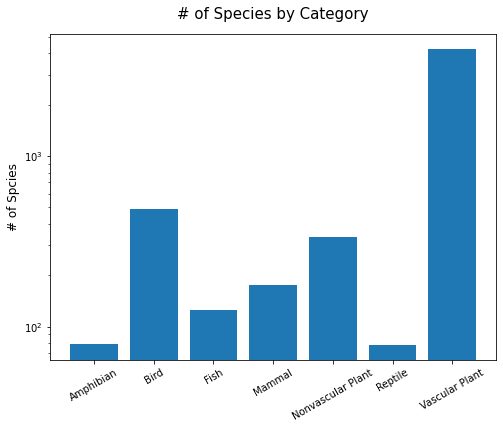

In [28]:
fig, ax = plt.subplots(figsize=(8,6))

plt.bar(spcies_df['category'], spcies_df['scientific_name']);
plt.yscale('log')
plt.xticks(rotation=30);
plt.title('# of Species by Category', pad=15, size=15);
plt.ylabel('# of Spcies', size=12);

-----------------------
## Analysis Question 1:
#### What is the distribution of conservation statuses across the different categories 
(e.g, do mammals have more animals in endangered than birds, etc.)

-----------------------

#### Distribution of Conservation Statuses 
Mammals include a total of 176 species, ranked only #4 in terms of total species. These are however, disproportionately represented in the "Endangered" category, compared to other biological groups. While birds have a higher number of species listed as "Species of Concern", the severity of risk is more concentrated for mammals and fish. We also observe that vascular plants, with the highest number of total species in the dataset, have a very low number of species at risk. Despite the high number of "Species of Concern" these are proportionately low when we consider the total number of species (~0.1%). This data suggests that the extinction risk in these parks is more prevalent for animal life than plant life. 

| Conservation Status | Mammal | Bird | Reptile | Amphibian | Fish | Vascular Plant | Nonvascular Plant |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Endangered** | 6 | 4 | 0 | 1 | 3 | 1 | 0 |
| **Threatened** | 2 | 0 | 0 | 2 | 4 | 2 | 0 |
| **Species of Concern** | 22 | 68 | 5 | 4 | 4 | 43 | 5 |
| **In Recovery** | 0 | 3 | 0 | 0 | 0 | 0 | 0 |
| **Data Deficient** | 146 | 413 | 73 | 72 | 114 | 4216 | 328 |
| **Total Species** | 176 | 488 | 78 | 79 | 125 | 4262 | 333 |

-----------------------
#### Analysis Process 
We begin by grouping species by category and conservation status, and counting the number of species in each conservation group by each category. 

the "Data Deficient" row highlights that a vast majority of species in the parks — especially vascular plants — have not yet been assigned a formal conservation risk level.


<b><u> Note </u></b>: \
The large number of "Data Defficient" conservation status will make it difficult to understand the distribution of other conservation parameters. \
We will remove these from the distribution plots in order to gain an understanding of what species are most at risk.

-----------------------

In [30]:
category_order = ['Mammal', 'Bird', 'Reptile', 'Amphibian', 'Fish', 'Vascular Plant', 'Nonvascular Plant']

temp_df = master_df.drop_duplicates(subset=['scientific_name', 'conservation_status'])
ct = pd.crosstab(temp_df.conservation_status, temp_df.category)
ct = ct.reindex(columns=category_order)
ct.index = ct.index.astype(str)
ct.loc['Total'] = ct.sum()
ct

category,Mammal,Bird,Reptile,Amphibian,Fish,Vascular Plant,Nonvascular Plant
conservation_status,,,,,,,
Endangered,6,4,0,1,3,1,0
Threatened,2,0,0,2,4,2,0
Species of Concern,22,68,5,4,4,43,5
In Recovery,0,3,0,0,0,0,0
Data Deficient,146,413,73,72,114,4216,328
Total,176,488,78,79,125,4262,333


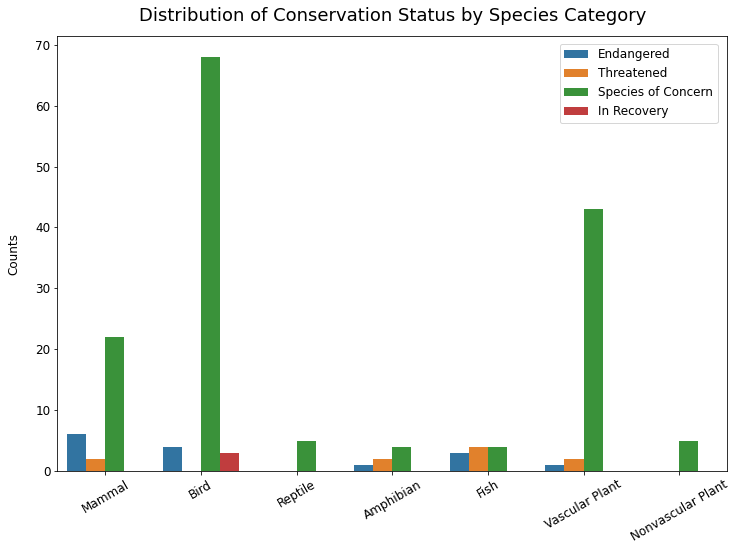

In [31]:
import seaborn as sns

# Filter for Data Deficient and remove empty categories 
plot_data = master_df[master_df.conservation_status != 'Data Deficient'].copy()
plot_data['conservation_status'] = plot_data['conservation_status'].cat.remove_unused_categories()
plot_data = plot_data.drop_duplicates(subset=['scientific_name', 'conservation_status'])

# Define an order we will use for both the crosstab and plot
status_order = ['Endangered', 'Threatened', 'Species of Concern', 'In Recovery']
category_order = ['Mammal', 'Bird', 'Reptile', 'Amphibian', 'Fish', 'Vascular Plant', 'Nonvascular Plant']

plt.figure(figsize=(12, 8))
sns.countplot(
    data=plot_data, 
    x='category', 
    hue='conservation_status', 
    order=category_order, 
    hue_order=status_order)

#plt.yscale('log')
plt.title('Distribution of Conservation Status by Species Category', pad=15, size=18);
plt.ylabel('Counts', labelpad=15, size=12);
plt.yticks(fontsize=12)
plt.xlabel('')
plt.xticks(fontsize=12, rotation=30);
plt.legend(loc=(0.75,0.80), fontsize='large');

-----------------------
## Analysis Question 2:

### Determine the populations of species with specific conservation needs
-----------------------

Next, we look at the percent of species at risk per category, to deepen our understanding of the previous analysis. We saw that Mammals are at a disproportionately high risk compared to other categories, and we'd like to get a sense of the % of total species impacted for each category. 

We begin by excluding "Data Deficient" and "In Recovery" species, and look at the percentage of species "At Risk" relative to the total number of species. 

### Category by percentage of total number of species under protection.
------------------------------------------
<code><u>Species at Risk</u>:     <b>['Endangered', 'Threatened', 'Species of Concern']</b></code>\
    <code><u>Species Not at Risk</u>: <b>['In Recovery', 'Data Deficient']</b></code>
------------------------------------------

#### Percentage of Species at Risk 

| Category | Total # Species | # Species At Risk | % Species At Risk
| ---: | :---: | :---: | :---: |
| **Mammal** | 176 | 30 | 17% |
| **Bird** | 488 | 72 | ~15% |
| **Amphibian** | 79 | 7 | ~9% | 
| **Fish** | 125 | 11 | ~9% | 
| **Reptile** | 78 |  5 | 6% | 
| **Nonvascular Plants** | 333 | 5 | 1.5% | 
| **Vascular Plants** | 4262 | 46 | 1% | 

<br> 

#### <b><u>Remarks</u></b>: 
We see that Mammals and birds are heavily impacted species, with about 15% of total species showing some level of risk. Fish and amphibians have a lower percentage of impacted species at about 10%, followed by Reptiles at 6%. Both Vascular and Non-Vascular plants have a very low number of impacted species. While The distribution plots above show a large number of species of concern for Vascular Plants, this is deceptive due to the large number of Vascular Plant species. The percentage values show both Vascular and Non-Vascular plants are relatively save. 

------------------------------------------

In [32]:
temp_df = master_df.copy()

excluded_statuses = ['Data Deficient', 'In Recovery']

temp_df['at_risk'] = ~temp_df.conservation_status.isin(excluded_statuses)
at_risk_counts = temp_df.groupby(['category', 'at_risk']).scientific_name.nunique().unstack().reset_index()
at_risk_counts.columns = ['category', 'not_at_risk', 'at_risk']
at_risk_counts['percent_at_risk'] = round((at_risk_counts.at_risk / (at_risk_counts.at_risk + at_risk_counts.not_at_risk) * 100), 2)
at_risk_counts = at_risk_counts.sort_values(by='percent_at_risk', ascending=False).reset_index(drop=True)

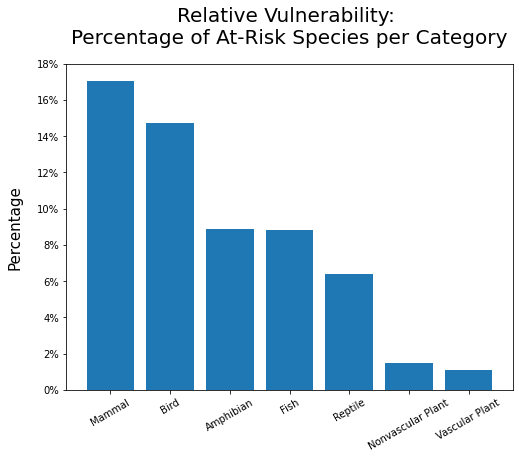

In [33]:
fig, ax = plt.subplots(figsize=(8,6))

plt.bar(at_risk_counts['category'], at_risk_counts['percent_at_risk']);

plt.xticks(rotation=30);
list_ticks = [f"{tick:.0f}%" for tick in ax.get_yticks()]
ax.set_yticks(ax.get_yticks())
ax.set_yticklabels(list_ticks)
plt.ylabel('Percentage', labelpad=15, size=15);
plt.title('Relative Vulnerability: \nPercentage of At-Risk Species per Category', size=20, pad=20);

### Total number of species under different conservations levels (high/mod/low risk)

Next, we look at the different levels  ofrisk per category, to deepen our understanding of the previous analysis. \
We break the risk levels up into High, Moderate and Low risk according to the following: 

------------------------------------------
<code><u>High Risk</u>:     <b>['Endangered']</b></code>\
<code><u>Moderate Risk</u>: <b>['Threatened', 'Species of Concern']</b></code>\
<code><u>Low Risk</u>:      <b>['In Recovery', 'Data Deficient']</b></code>

------------------------------------------

#### Number of Species in High/Mod/Low Risk Levels 

| category | # High Risk Species | # Moderate Risk Species | # Low Risk Species
| ---: | :---: | :---: | :---: |
| **Mammal** | 6 | 24 | 146 |
| **Bird** | 4 | 68 | 416 | 
| **Amphibian** | 1 | 60 | 72 |
| **Fish** | 3 | 8 | 114 |
| **Reptile** | 0 | 5 | 73 |
| **Nonvascular Plant** | 0 |5 | 328 |
| **Vascular Plant** | 1 | 45 | 4216 |

In [34]:
high_risk = ['Endangered']
mod_risk = ['Threatened', 'Species of Concern']
low_risk = ['In Recovery', 'Data Deficient']

conditions = [master_df.conservation_status.isin(high_risk), 
              master_df.conservation_status.isin(mod_risk),
              master_df.conservation_status.isin(low_risk)]

choices = ['high_risk', 'moderate_risk', 'low_risk']

master_df['risk_level'] = np.select(conditions, choices, default='N/A')
master_df

,category,scientific_name,common_names,park_name,observations,conservation_status,risk_level
0,Vascular Plant,Abies bifolia,Rocky Mountain Alpine Fir,Bryce National Park,109,Data Deficient,low_risk
1,Vascular Plant,Abies concolor,"Balsam Fir, Colorado Fir, Concolor Fir, Silver...",Bryce National Park,83,Data Deficient,low_risk
2,Vascular Plant,Abies fraseri,Fraser Fir,Bryce National Park,109,Species of Concern,moderate_risk
3,Nonvascular Plant,Abietinella abietina,Abietinella Moss,Bryce National Park,101,Data Deficient,low_risk
4,Vascular Plant,Abronia ammophila,"Wyoming Sand Verbena, Yellowstone Sand Verbena",Bryce National Park,92,Species of Concern,moderate_risk
...,...,...,...,...,...,...,...
22159,Bird,Zonotrichia leucophrys gambelii,Gambel's White-Crowned Sparrow,Yosemite National Park,169,Data Deficient,low_risk
22160,Bird,Zonotrichia leucophrys oriantha,Mountain White-Crowned Sparrow,Yosemite National Park,135,Data Deficient,low_risk
22161,Bird,Zonotrichia querula,Harris's Sparrow,Yosemite National Park,160,Data Deficient,low_risk
22162,Nonvascular Plant,Zygodon viridissimus,Zygodon Moss,Yosemite National Park,159,Data Deficient,low_risk


In [35]:
temp_df = master_df.copy()

temp_df = temp_df.groupby(['category', 'risk_level']).scientific_name.nunique().unstack().fillna(0).reset_index()
temp_df = temp_df.rename_axis(None, axis=1)
new_order = ['category', 'high_risk', 'moderate_risk', 'low_risk']
temp_df = temp_df[new_order]
temp_df

,category,high_risk,moderate_risk,low_risk
0,Amphibian,1.0,6.0,72.0
1,Bird,4.0,68.0,416.0
2,Fish,3.0,8.0,114.0
3,Mammal,6.0,24.0,146.0
4,Nonvascular Plant,0.0,5.0,328.0
5,Reptile,0.0,5.0,73.0
6,Vascular Plant,1.0,45.0,4216.0


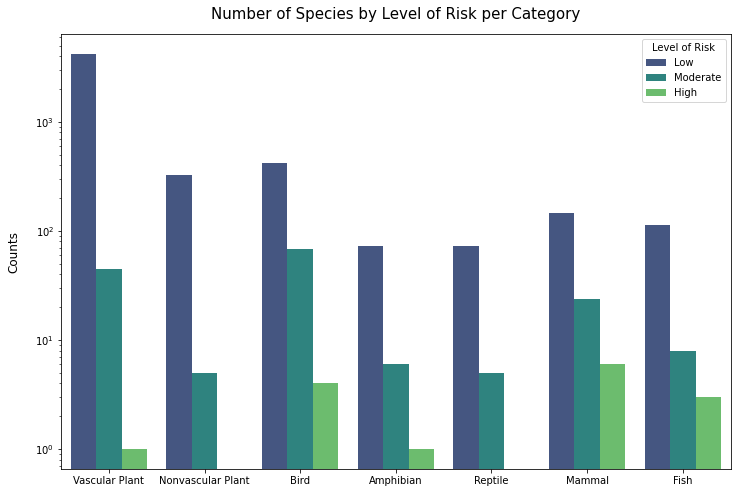

In [49]:
temp_df = master_df.drop_duplicates(subset=['scientific_name', 'risk_level'])

plt.figure(figsize=(12, 8));

colors={'low_risk':'tab:green', 'moderate_risk':'tab:orange', 'high_risk':'tab:red'}

risk_levels = ['Low', 'Moderate', 'High']

sns.countplot(
    data=test_df, 
    x='category', 
    hue='risk_level',
    palette='viridis');

plt.yscale('log');
plt.title('Number of Species by Level of Risk per Category', pad=15, size=15)
plt.xlabel('');
plt.ylabel('Counts', labelpad=15, size=12);
plt.legend(risk_levels, title='Level of Risk');

------------------------------------------
### Conclusions
------------------------------------------


- <b> categories with highest risk statuses: </b> \
From both the percentage of species under protection and the risk level of each species, we can see that mammals are at the highest risk, \
both in percentange of species impacted (17% of all mammal species are under protection), where 6/30 (20%) of protected species are at high risk. \
Birds follow with a high number of total species at risk (72) making up 15% of the total bird species. When we look at the severity of risk, \
4/72 species at risk ($\approx$ 6%) fall in the high risk category. Fish species have the highest percentage of high risk species (i.e.: 3/11 ($\approx$ 27%)).

- <b> categories completely missing from high-risk statuses: </b> \
Reptiles and Non Vascular plants are completely missing from high-risk statuses. The species underprotection are only classed as species of concern, \
which include only 5% of the total species.  

- <b> State whether the distribution is skewed toward specific animal classes, such as Mammals or Birds, versus others. </b> \
Mammals and fish have the highest portion of high risk species, and birds have a high number of species of concern, along with several high risk species. \
Reptiles and Nonvascular plants have the least number of at risk species. 

-----------------------
## Analysis Question 3:

- Evaluate which locations have the greatest biodiversity - which park has the greatest sightings of rare species? 
-----------------------

Linking the species information with observation data allowed us to identify the "Top 100 Rarest Species," which were defined as those with the lowest total sighting counts across all four parks.

<br> 

| Park Name | Rare Observations | Normalized Observations |
| :--- | :---: | :---: |
| Yellowstone National Park | 18,686 | 1.29 |
| Yosemite National Park | 10,751 | 1.25 |
| Bryce National Park | 6,788 | 1.18 |
| Great Smoky Mountains National Park | 4,333 | 1.00 |

<br>

-----------------------

In [50]:
species_by_observation = master_df.groupby(['category', 'scientific_name', 'common_names', 'conservation_status'], observed=True)['observations'].sum().reset_index()
top_ten_rarest = species_by_observation.sort_values(by='observations').reset_index(drop=True).head(100)
top_hundred_rarest = list(top_ten_rarest['scientific_name'])

In [51]:
df_test = master_df.copy()

df_test_1 = df_test[df_test['scientific_name'].isin(top_hundred_rarest)]
df_test_1 = df_test_1.groupby(['park_name'])['observations'].sum().reset_index()
df_test_1.columns = ('park_name', 'rare_observations')

df_test_2 = df_test.groupby(['park_name'])['observations'].sum().reset_index()

df_test_1['normalized_observations'] = round((df_test_1['rare_observations'] / df_test_2['observations']) * 100, 2)
df_test_1 = df_test_1.sort_values(by='normalized_observations', ascending=False)

In [52]:
df_test_1.reset_index(drop=True)

,park_name,rare_observations,normalized_observations
0,Yellowstone National Park,18686,1.29
1,Yosemite National Park,10751,1.25
2,Bryce National Park,6788,1.18
3,Great Smoky Mountains National Park,4333,1.00


-----------------------

Using this info, we look at what category includes the top 100 rarest species: 

| Category | Unique Species Count |
| :--- | :---: |
| Vascular Plant | 50 |
| Bird | 26 |
| Mammal | 9 |
| Fish | 6 |
| Amphibian | 4 |
| Reptile | 3 |
| Nonvascular Plant | 2 |

The rarest species of vascular plants likely do not belong to a protected conservation status, however, the bird, mammal and fish species likely do. We can deduce this from our previous analysis on the percentage of species in each conservation group from before.  


<br> 

| Category | Endangered | Threatened | Species of Concern | In Recovery | Data Deficient |
| :--- | :---: | :---: | :---: | :---: | :---: |
| **Mammal** | 5 | 2 | 2 | 0 | 0 |
| **Bird** | 4 | 0 | 14 | 3 | 5 |
| **Fish** | 3 | 3 | 0 | 0 | 0 |
| **Amphibian** | 1 | 2 | 0 | 0 | 1 |
| **Vascular Plant** | 1 | 2 | 10 | 0 | 37 |
| **Nonvascular Plant** | 0 | 0 | 0 | 0 | 2 |
| **Reptile** | 0 | 0 | 2 | 0 | 1 |

<br> 

Predictably, majority of species with low observation have a high risk of endagerment - lower species population leads to lower observations. \
We see an inverse in this scale as we move from animals species like mammals, birds and fish and into vascular plants. The biggest exception to the rule are reptiles. \
Rare species of reptiles are at relatively low risk in terms of conservation status.

-----------------------

In [53]:
df_test = master_df.copy()

df_test2 = df_test[df_test['scientific_name'].isin(top_hundred_rarest)]
df_test2 = df_test2.groupby(['category'])['scientific_name'].nunique().reset_index()
df_test2.sort_values(by='scientific_name', ascending=False)

,category,scientific_name
6,Vascular Plant,50
1,Bird,26
3,Mammal,9
2,Fish,6
0,Amphibian,4
5,Reptile,3
4,Nonvascular Plant,2


In [54]:
df_test = master_df.copy()

df_rare_species = df_test[df_test['scientific_name'].isin(top_hundred_rarest)]
df_rare_species = df_rare_species.groupby(['category', 'conservation_status'])['scientific_name'].nunique().unstack().sort_values(by='Endangered', ascending=False)

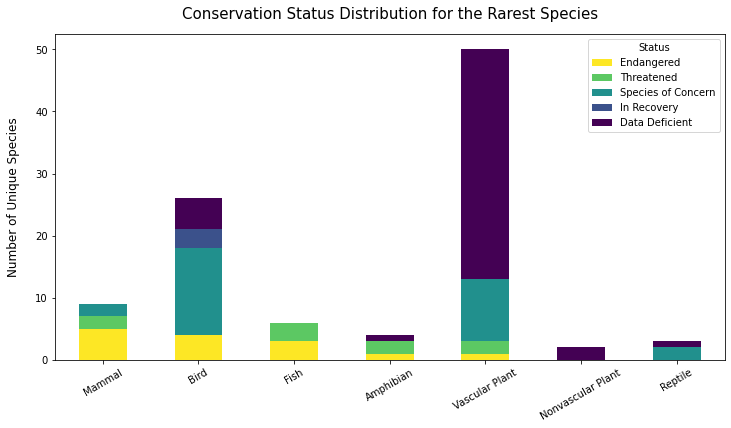

In [55]:
fig, ax = plt.subplots(figsize=(12, 6));

df_rare_species.plot(kind='bar', stacked=True, ax=ax, colormap='viridis_r')

plt.title('Conservation Status Distribution for the Rarest Species', pad=15, size=15)
plt.xlabel('');
plt.ylabel('Number of Unique Species', labelpad=15, size=12);
plt.xticks(rotation=30);
plt.legend(title='Status');

-----------------------------------
### Sightings and Biodiversity Hotspots

By aggregating millions of sightings across the four parks, Yellowstone National Park emerged as the most active location for biodiversity monitoring, hosting the highest volume of both total and rare species observations. Yosemite is also a significant park in terms of conservation  However, when normalizing the data to account for this massive scale, we found that Bryce National Park actually holds a very competitive "rare species density." This suggests that while Yellowstone provides the largest sanctuary in terms of raw numbers, smaller parks like Bryce and Yosemite play an equally critical role in providing concentrated habitats for the system's most elusive species.


There are some very intersting discoveries when we look at the following heat map: 

<img src='heatmap.png' width='600'>

Yellowstone and Yosemite National Parks seem to be a hotspots for rare bird, plant (vascular and non-vascular) and amphibian/reptile species. \
Meanwhile Great Smoky Mountains National Park hosts an astonishing number of rare mammal and fish species, which are highly threatened species categories. \ 

| Park Name | Square Milage |
| :--- | :---: |
| Yellowstone | 3,472 |
| Yosemite | 1,187 |
| Great Smoky Mountains | 816 |
| Bryce | 56 |


-----------------------------------

In [56]:
park_names = []

for park in df_test_1['park_name']:
    words = park.split(' ')
    short_name = ' '.join(words[:-2])
    park_names.append(short_name)

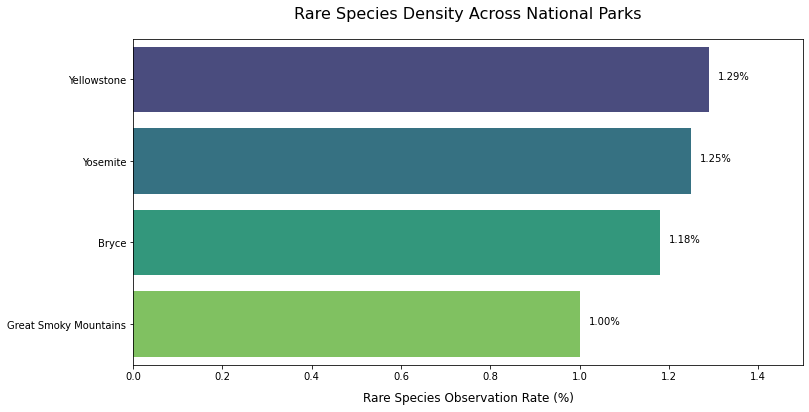

In [57]:
fig, ax = plt.subplots(figsize=(12,6));

sns.barplot(x=df_test_1['normalized_observations'], y='park_name', data=df_test_1, palette='viridis');
plt.xlabel('Rare Species Observation Rate (%)', fontsize=12, labelpad=10)
plt.ylabel('')
ax.set_yticks(ax.get_yticks());
ax.set_yticklabels(park_names);
plt.title('Rare Species Density Across National Parks', size=16, pad=20);
plt.xlim(0, 1.5);

plt.text(1.31, 0, '1.29%', size=10);
plt.text(1.27, 1, '1.25%', size=10);
plt.text(1.20, 2, '1.18%', size=10);
plt.text(1.02, 3, '1.00%', size=10);

In [58]:
df_test = master_df.copy()

df_test_2 = master_df.copy()
df_test_2 = df_test_2.groupby(['category', 'park_name'])['observations'].sum().reset_index()

df_test = df_test[df_test['scientific_name'].isin(top_hundred_rarest)]
df_test = df_test.groupby(['category', 'park_name'])['observations'].sum().reset_index()
df_test['observation_density'] = df_test['observations']/df_test_2['observations'] * 100

df_pivot = df_test.pivot(index='category', columns='park_name', values='observation_density')

In [59]:
park_names = []

for column in df_pivot.columns:
    words = column.split(' ')
    finished_word = ' '.join(words[:-2])
    park_names.append(finished_word)

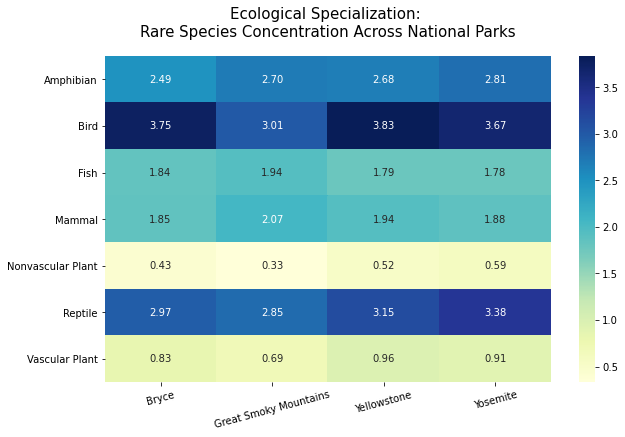

In [71]:
fig, ax = plt.subplots(figsize=(10,6))

sns.heatmap(df_pivot, annot=True, fmt='.2f', cmap='YlGnBu');
ax.set_xticks(ax.get_xticks());
ax.set_xticklabels(park_names);
ax.tick_params(axis='x', rotation=15);
plt.xlabel('');
plt.ylabel('');
plt.title('Ecological Specialization: \nRare Species Concentration Across National Parks', size=15, pad=20);
plt.savefig('heatmap.png', facecolor='white', transparent=False, bbox_inches='tight', dpi=300)